# Huấn luyện mô hình ResNet-50 để phát hiện Viêm Phổi

**Môn học:** Xử Lý Ảnh Số  
**Đề tài:** Phân loại ảnh X-quang phổi (Normal vs Pneumonia)  
**Mô hình:** ResNet-50 (Transfer Learning)

---

## Mục tiêu:
1. Sử dụng dữ liệu đã tiền xử lý (CLAHE, resize, augmentation)
2. Fine-tune ResNet-50 pretrained trên ImageNet
3. Đánh giá hiệu suất trên tập test
4. So sánh với CNN tự xây dựng

---

## Dataset sau tiền xử lý:
- **Train:** 7,278 Normal + 10,323 Pneumonia = **17,601 ảnh**
- **Val:** 135 Normal + 416 Pneumonia = **551 ảnh**
- **Test:** 231 Normal + 387 Pneumonia = **618 ảnh**
- **Kích thước:** 256x256 (đã resize với padding)
- **Xử lý:** CLAHE + Homomorphic Filter + Augmentation

## Bước 1: Khởi Tạo Môi Trường và Tải Dữ Liệu

Trong bước này, chúng em sẽ thiết lập môi trường làm việc bằng cách nhập các thư viện Python cần thiết, kiểm tra thiết bị tính toán (CPU/GPU) và tải bộ dữ liệu X-quang phổi từ Kaggle.

### 1.1. Import các Thư viện Cần thiết

chúng em cần nhập các thư viện chuyên dụng cho xử lý số liệu, học sâu, trực quan hóa và đánh giá mô hình.

In [1]:
# Các thư viện cơ bản của Python
import os
import json
from datetime import datetime

# Thư viện xử lý số liệu
import numpy as np
import pandas as pd

# Thư viện vẽ biểu đồ và trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện tải dữ liệu từ Kaggle
import kagglehub

# -------------------- PYTORCH --------------------
import torch
from torch import amp
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

# Để đảm bảo sự cân bằng giữa các lớp trong quá trình huấn luyện
from torch.utils.data import WeightedRandomSampler

# AMP chuẩn mới (Automatic Mixed Precision) của PyTorch
from torch.cuda.amp import autocast, GradScaler

# Các hàm tiện ích của PyTorch
import torch.nn.functional as F

# -------------------- Đánh giá mô hình (Scikit-learn) --------------------
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    matthews_corrcoef, cohen_kappa_score
)

# -------------------- Xử lý ảnh và tiện ích --------------------
from PIL import Image
import cv2

from tqdm import tqdm # Thư viện tạo thanh tiến trình

### 1.2. Thiết lập Cấu hình Môi trường

Thiết lập seed ngẫu nhiên để đảm bảo tính tái lập của kết quả, kiểm tra thiết bị GPU, và cấu hình hiển thị biểu đồ.

In [2]:
# Đặt seed để kết quả có thể tái lập
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Kiểm tra thiết bị (CPU hoặc GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Sử dụng thiết bị:", device)
print("Phiên bản PyTorch:", torch.__version__)

# Cấu hình hiển thị cho matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

Sử dụng thiết bị: cuda
Phiên bản PyTorch: 2.6.0+cu124


**Kết quả chạy:**

> Sử dụng thiết bị: cuda (hoặc cpu)
> Phiên bản PyTorch: 2.x.x (hoặc phiên bản hiện tại)

### 1.3. Tải Dữ liệu từ Kaggle

Sử dụng thư viện `kagglehub` để tự động tải bộ dữ liệu đã được tiền xử lý về máy tính.

In [3]:
# Tải dataset từ Kaggle
# Lưu ý: Tên dataset là nguyendinhtanloc1/chest-xray
dataset_path = kagglehub.dataset_download("nguyendinhtanloc1/chest-xray")
print("Dataset được tải vào thư mục:", dataset_path)

# Hiển thị nội dung trong thư mục dataset
print("\nNội dung trong thư mục dataset:")
print(os.listdir(dataset_path))

# Kiểm tra thư mục processed_final
print("\nNội dung trong processed_final:")
print(os.listdir(os.path.join(dataset_path, "processed_final")))


Dataset được tải vào thư mục: /kaggle/input/

Nội dung trong thư mục dataset:
['processed_final']

Nội dung trong processed_final:
['val', 'test', 'train']


**Kết quả chạy:**

> Dataset được tải vào thư mục: /path/to/dataset/nguyendinhtanloc1/chest-xray
>
> Nội dung trong thư mục dataset:
> ['test', 'train', 'val']

## Bước 2: Xây Dựng Lớp Dữ liệu Tùy chỉnh (`Custom Dataset`)

Để PyTorch có thể làm việc hiệu quả với dữ liệu ảnh X-quang, chúng em cần tạo một lớp kế thừa từ `torch.utils.data.Dataset`. Lớp này sẽ chịu trách nhiệm đọc đường dẫn ảnh, xác định nhãn tương ứng và áp dụng các phép biến đổi ảnh (transform).

### 2.1. Cấu Trúc Thư Mục Dữ liệu Đầu vào

Dữ liệu ảnh X-quang đã được tổ chức theo cấu trúc tiêu chuẩn, trong đó tên thư mục con đóng vai trò là nhãn (label) của ảnh.

```
/path/to/dataset/chest-xray/
├── train/
│   ├── NORMAL/    (Label 0: Bình thường)
│   └── PNEUMONIA/ (Label 1: Viêm phổi)
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

### 2.2. Định nghĩa Class `ChestXrayDataset`

Class này sẽ tự động thu thập đường dẫn ảnh từ hai thư mục `NORMAL` và `PNEUMONIA`. Tuy nhiên, trong đoạn code này, việc xác định nhãn (label) cho từng ảnh đang bị thiếu trong phương thức `__init__` và `__getitem__`.

**Lưu ý quan trọng:** Cần điều chỉnh code để lấy được **nhãn số (0 hoặc 1)** từ tên thư mục chứa ảnh.

#### Code Của Lớp Dataset

In [4]:
# Định nghĩa lớp Dataset để đọc ảnh X-quang ngực
class ChestXrayDataset(Dataset):
    """
    Lớp Dataset tùy chỉnh để load ảnh X-quang ngực và gán nhãn dựa trên
    cấu trúc thư mục (NORMAL: 0, PNEUMONIA: 1).
    """
    def __init__(self, data_dir, transform=None):
        # Lưu đường dẫn dữ liệu và phép biến đổi (transform) nếu có
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {'NORMAL': 0, 'PNEUMONIA': 1} # Ánh xạ nhãn

        # Duyệt qua các thư mục con (là tên nhãn)
        print(f"Bắt đầu load dữ liệu từ: {data_dir}")
        for label_name, label_idx in self.class_to_idx.items():
            label_path = os.path.join(data_dir, label_name)
            
            # Chỉ xử lý nếu thư mục tồn tại
            if os.path.isdir(label_path):
                # Lấy danh sách đường dẫn ảnh
                image_files = [
                    os.path.join(label_path, f)
                    for f in os.listdir(label_path)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))
                ]
                
                # Cập nhật danh sách đường dẫn và nhãn
                self.image_paths.extend(image_files)
                self.labels.extend([label_idx] * len(image_files))
                
                print(f"  - Đã load {len(image_files)} ảnh từ thư mục '{label_name}' (Label: {label_idx})")

        print(f"Hoàn tất. Tổng số ảnh đã load: {len(self.image_paths)}")

    def __len__(self):
        # Trả về tổng số ảnh trong dataset
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Lấy đường dẫn ảnh và nhãn theo thứ tự
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Đọc ảnh và chuyển về RGB (đảm bảo 3 kênh màu)
        image = Image.open(img_path).convert("RGB")

        # Áp dụng transform nếu có
        if self.transform:
            image = self.transform(image)

        # Trả về ảnh (dạng tensor) và nhãn (dạng số)
        return image, label

### 2.3. Kiểm Tra Hoạt động của Dataset

Kiểm tra xem lớp `ChestXrayDataset` đã đọc đúng số lượng ảnh từ thư mục huấn luyện (Train) chưa, dựa trên thông tin đã cung cấp ở phần giới thiệu đồ án.

In [5]:
print("\n=== KIỂM TRA DATASET LOADER ===")

# Đường dẫn dataset gốc đã tải từ Kaggle ở Bước 1
# Dataset thực tế nằm trong thư mục: processed_final/train
train_dir = os.path.join(dataset_path, "processed_final", "train")
print(f"Đang kiểm tra: {train_dir}")

# Load thử dataset để kiểm tra hoạt động
temp_dataset = ChestXrayDataset(train_dir)

# Kiểm tra số lượng ảnh
print("Tổng số ảnh:", len(temp_dataset))
if len(temp_dataset) > 0:
    # Kiểm tra ngẫu nhiên một phần tử để xác nhận định dạng
    sample_image, sample_label = temp_dataset[0]
    print(f"\nKiểm tra phần tử đầu tiên:")
    print(f" - Định dạng ảnh: {type(sample_image)} (trước khi transform)")
    print(f" - Nhãn: {sample_label}")
    print("Dataset hoạt động tốt, sẵn sàng cho bước tiếp theo!")
else:
    print("Không tìm thấy ảnh nào trong dataset. Kiểm tra lại cấu trúc thư mục hoặc tên nhãn (NORMAL/PNEUMONIA).")



=== KIỂM TRA DATASET LOADER ===
Đang kiểm tra: /kaggle/input/processed_final/train
Bắt đầu load dữ liệu từ: /kaggle/input/processed_final/train
  - Đã load 7278 ảnh từ thư mục 'NORMAL' (Label: 0)
  - Đã load 10323 ảnh từ thư mục 'PNEUMONIA' (Label: 1)
Hoàn tất. Tổng số ảnh đã load: 17601
Tổng số ảnh: 17601

Kiểm tra phần tử đầu tiên:
 - Định dạng ảnh: <class 'PIL.Image.Image'> (trước khi transform)
 - Nhãn: 0
Dataset hoạt động tốt, sẵn sàng cho bước tiếp theo!


## Bước 3: Định nghĩa Biến đổi (Transform) và Tạo DataLoaders

Trước khi đưa dữ liệu vào mô hình, chúng em cần xác định các phép biến đổi (Transform) cho ảnh và tổ chức dữ liệu thành các gói nhỏ (Batch) thông qua `DataLoader`.

### 3.1. Định nghĩa các Phép Biến đổi Ảnh (Transforms)

Các phép biến đổi đóng vai trò quan trọng trong việc chuẩn hóa dữ liệu và tăng cường khả năng học tổng quát của mô hình. chúng em sử dụng hai loại Transform:

  * **Tập Train (Huấn luyện):** Bao gồm nhiều kỹ thuật **tăng cường dữ liệu (Augmentation)** để mô hình làm quen với các biến thể của ảnh (xoay, lật, thay đổi màu sắc,...).
  * **Tập Val/Test (Kiểm tra):** Chỉ thực hiện chuẩn hóa và cắt ảnh (Center Crop) để đảm bảo tính khách quan và nhất quán của dữ liệu kiểm tra.

In [6]:
# Mean và Std được lấy từ ImageNet để phù hợp với ResNet-50 Pre-trained
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
TARGET_SIZE = 224 # Kích thước chuẩn đầu vào cho ResNet

# Transform cho tập train: gồm các bước tăng cường dữ liệu và chuẩn hóa
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(TARGET_SIZE), # Cắt ngẫu nhiên và resize về 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),  # <-- đã xóa ký tự U+00A0
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Dịch chuyển ảnh nhẹ
    transforms.ToTensor(), # Chuyển ảnh PIL/NumPy thành PyTorch Tensor (0-1)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # Chuẩn hóa theo ImageNet
])

# Transform cho tập val và test: chỉ resize và chuẩn hóa, không có augmentation
val_test_transform = transforms.Compose([
    transforms.Resize(256), # Resize ảnh lớn hơn (256x256)
    transforms.CenterCrop(TARGET_SIZE), # Cắt chính giữa về kích thước 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

### 3.2. Tạo DataSets và DataLoaders

chúng em sử dụng class `ImageFolder` có sẵn trong `torchvision` vì cấu trúc thư mục dữ liệu đã được tổ chức theo tiêu chuẩn của PyTorch.

#### a) Định nghĩa DataSets

In [7]:
print("=== TẠO DATASETS ===")

# Đường dẫn dataset thực tế: processed_final/train, processed_final/val, processed_final/test
TRAIN_DIR = os.path.join(dataset_path, "processed_final", "train")
VAL_DIR   = os.path.join(dataset_path, "processed_final", "val")
TEST_DIR  = os.path.join(dataset_path, "processed_final", "test")

# Tạo dataset cho từng tập bằng ImageFolder
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = ImageFolder(TEST_DIR, transform=val_test_transform)  # <-- đã bỏ ký tự U+00A0

print(f"Train Dataset: {len(train_dataset.samples)} ảnh. Classes: {train_dataset.class_to_idx}")
print(f"Val Dataset: {len(val_dataset.samples)} ảnh.")
print(f"Test Dataset: {len(test_dataset.samples)} ảnh.")


=== TẠO DATASETS ===
Train Dataset: 17601 ảnh. Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Val Dataset: 551 ảnh.
Test Dataset: 618 ảnh.


#### b) Tạo DataLoaders (Xử lý Mất Cân bằng Dữ liệu)

Do số lượng ảnh Viêm phổi (Pneumonia) nhiều hơn ảnh Bình thường (Normal) trong tập Train, chúng em sử dụng **`WeightedRandomSampler`** để cân bằng lại xác suất chọn mẫu giữa hai lớp, giúp mô hình không bị thiên vị cho lớp đa số.

In [8]:
print("\n=== TẠO DATALOADERS ===")

BATCH_SIZE = 32
NUM_WORKERS = 2

# Xử lý Mất Cân bằng Dữ liệu (Imbalanced Data) bằng WeightedRandomSampler

# 1. Lấy nhãn của tất cả ảnh trong tập train
targets = train_dataset.targets 

# 2. Đếm số lượng ảnh của mỗi lớp (Normal=0, Pneumonia=1)
class_sample_count = np.bincount(targets)

# 3. Tính trọng số ngược (Inverse Weight) cho mỗi lớp
weights = 1. / class_sample_count

# 4. Ánh xạ trọng số ngược vào từng ảnh cụ thể
sample_weights = [weights[t] for t in targets]

# 5. Tạo Sampler để lấy mẫu cân bằng hơn khi training
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),  # Số lần lấy mẫu bằng với số lượng dữ liệu
    replacement=True                  # Cho phép lấy mẫu lặp lại
)

# Tạo dataloaders
# Train Loader sử dụng Sampler, không cần shuffle=True
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Val/Test Loader sử dụng shuffle=False (không xáo trộn)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train Loader: {len(train_loader)} batches (Weighted Sampling)")
print(f"Val Loader: {len(val_loader)} batches")
print(f"Test Loader: {len(test_loader)} batches")


=== TẠO DATALOADERS ===
Train Loader: 551 batches (Weighted Sampling)
Val Loader: 18 batches
Test Loader: 20 batches


## Bước 4: Xây Dựng và Tinh chỉnh Mô hình ResNet-50 (Transfer Learning)

Bước này là trọng tâm của đồ án, nơi chúng em áp dụng kỹ thuật **Học chuyển giao (Transfer Learning)** bằng cách tinh chỉnh mô hình ResNet-50 đã được huấn luyện sẵn.

### 4.1. Khái niệm về ResNet-50 và Học chuyển giao

**ResNet-50** là một trong những kiến trúc Mạng nơ-ron tích chập (CNN) sâu và hiệu quả nhất, nổi bật với việc sử dụng **Khối dư (Residual Block)**.  Khối này giúp mô hình giải quyết vấn đề gradient biến mất khi tăng độ sâu (50 lớp), cho phép học được các đặc trưng phức tạp hơn.

**Học chuyển giao (Transfer Learning):** chúng em sử dụng mô hình ResNet-50 đã được huấn luyện trên bộ dữ liệu khổng lồ ImageNet (1.4 triệu ảnh, 1000 lớp). Kỹ thuật này giúp mô hình của chúng em:

1.  **Tận dụng kiến thức cơ bản:** Mô hình đã học cách nhận diện các đặc trưng chung như đường nét, góc cạnh, và kết cấu.
2.  **Tăng tốc huấn luyện:** Chỉ cần tinh chỉnh các lớp cuối cùng để thích nghi với ảnh X-quang, giảm đáng kể thời gian huấn luyện.
3.  **Đạt độ chính xác cao hơn** so với việc huấn luyện mô hình từ đầu (from scratch).

### 4.2. Triển khai Tinh chỉnh Mô hình

chúng em sẽ tải mô hình ResNet-50 đã được huấn luyện sẵn và thay đổi lớp phân loại đầu ra (`model.fc`) để phù hợp với bài toán 2 lớp (Bình thường/Viêm phổi).

In [9]:
print("=== XÂY DỰNG MÔ HÌNH ===")

# Bước 1: Load mô hình ResNet-50 đã được pretrained trên bộ ImageNet
# Sử dụng trọng số IMAGENET1K_V2, đây là phiên bản mới nhất và tối ưu nhất
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
print("Đã load ResNet-50 với pretrained weights từ ImageNet")

# Bước 2: In ra kiến trúc gốc của ResNet-50 để quan sát lớp FC ban đầu
# Lớp này ban đầu có 1000 đầu ra (tương ứng 1000 lớp của ImageNet)
print("\nKiến trúc gốc của ResNet-50:")
print("  - Original FC layer:", model.fc)

# Bước 3: Thay đổi lớp FC cuối để phù hợp với bài toán phân loại 2 lớp
num_features = model.fc.in_features  # Lấy số chiều đầu vào của FC (2048)
# Định nghĩa lớp Fully Connected mới với 2 đầu ra (cho 2 classes)
model.fc = nn.Linear(num_features, 2)

print("\nSau khi thay đổi FC layer (Chuyển sang 2 đầu ra):")
print("  - New FC:", model.fc)

# Bước 4: Đưa mô hình sang GPU hoặc CPU tùy theo thiết bị đã kiểm tra ở Bước 1
model = model.to(device)
print("\nModel đã được đưa sang:", device)

# Bước 5: Kiểm tra số lượng parameters trong mô hình
total_params = sum(p.numel() for p in model.parameters())
# Do không đóng băng bất kỳ layer nào, tất cả đều là trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n=== KIỂM TRA THAM SỐ (PARAMETER CHECK) ===")
print("Tổng số parameters:", f"{total_params:,} (Hầu hết là từ các lớp convolution đã được huấn luyện)")
print("Trainable parameters:", f"{trainable_params:,} (Tất cả tham số đều được fine-tune)")

=== XÂY DỰNG MÔ HÌNH ===


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s] 


Đã load ResNet-50 với pretrained weights từ ImageNet

Kiến trúc gốc của ResNet-50:
  - Original FC layer: Linear(in_features=2048, out_features=1000, bias=True)

Sau khi thay đổi FC layer (Chuyển sang 2 đầu ra):
  - New FC: Linear(in_features=2048, out_features=2, bias=True)

Model đã được đưa sang: cuda

=== KIỂM TRA THAM SỐ (PARAMETER CHECK) ===
Tổng số parameters: 23,512,130 (Hầu hết là từ các lớp convolution đã được huấn luyện)
Trainable parameters: 23,512,130 (Tất cả tham số đều được fine-tune)


## Bước 5: Thiết lập Hàm Mất Mát (Loss Function) và Bộ Tối ưu hóa (Optimizer)

Việc thiết lập các thành phần này là tối quan trọng để quá trình huấn luyện diễn ra hiệu quả, đặc biệt khi phải đối mặt với vấn đề **mất cân bằng dữ liệu** (Class Imbalance).

### 5.1. Xử lý Vấn đề Mất cân bằng Lớp (Class Imbalance)

Tập dữ liệu huấn luyện của chúng em có số lượng ảnh **Viêm phổi (Pneumonia)** nhiều hơn **Bình thường (Normal)** (10,323 so với 7,278). Để tránh mô hình thiên vị lớp đa số, chúng em sử dụng hai giải pháp kết hợp:

1.  **WeightedRandomSampler** (Đã thực hiện ở Bước 3): Cân bằng xác suất chọn mẫu.
2.  **Class Weights trong Loss Function:** Gán trọng số cao hơn cho lớp thiểu số (Normal) trong hàm mất mát.

#### Code Tính Trọng số Lớp



In [10]:
print("=== THIẾT LẬP TRAINING ===")

# Bước 1: Xác định số lượng mẫu mỗi lớp trong tập train
num_normal = 7278
num_pneumonia = 10323

# Bước 2: Tính trọng số ngược cho từng lớp
# Trọng số Normal = Số mẫu Pneumonia / Số mẫu Normal
weight_normal = num_pneumonia / num_normal
weight_pneum = 1.0 # Lớp đa số giữ nguyên trọng số 1.0
class_weights = torch.tensor([weight_normal, weight_pneum], dtype=torch.float).to(device)

print("Class Weights được tính dựa trên tỷ lệ ngược:")
print("  - Normal (label=0):", f"{weight_normal:.3f} (Cao hơn vì ít mẫu hơn)")
print("  - Pneumonia (label=1):", f"{weight_pneum:.3f}")

=== THIẾT LẬP TRAINING ===
Class Weights được tính dựa trên tỷ lệ ngược:
  - Normal (label=0): 1.418 (Cao hơn vì ít mẫu hơn)
  - Pneumonia (label=1): 1.000


### 5.2. Định nghĩa Hàm Mất Mát Đặc biệt: Focal Loss

Thay vì sử dụng Cross Entropy Loss thông thường, chúng em chọn **Focal Loss** . Hàm mất mát này được thiết kế để **giảm trọng số** của các mẫu dễ dự đoán (mẫu mà mô hình đã làm đúng với độ tự tin cao) và **tăng trọng số** của các mẫu khó, giúp mô hình tập trung học hỏi từ các trường hợp phức tạp.

#### Code Class FocalLoss

In [11]:
# Bước 3: Cài đặt hàm Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha # Trọng số lớp (class weights)
        self.gamma = gamma # Tham số tập trung (focusing parameter)
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Tính Cross Entropy Loss cơ bản
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        
        # 2. pt là xác suất dự đoán đúng (Probability of correct classification)
        pt = torch.exp(-ce_loss)
        
        # 3. Công thức Focal Loss: (1 - pt)^gamma * CE Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss

# Bước 4: Khởi tạo loss function với class weights và gamma=2.0
criterion = FocalLoss(alpha=class_weights, gamma=2.0)
print("\nLoss: FocalLoss (gamma=2.0, dùng class weights) được sử dụng để giải quyết Class Imbalance")


Loss: FocalLoss (gamma=2.0, dùng class weights) được sử dụng để giải quyết Class Imbalance


### 5.3. Thiết lập Optimizer và Learning Rate Scheduler

chúng em sử dụng **AdamW** - một phiên bản cải tiến của Adam, kết hợp với bộ điều chỉnh tốc độ học (LR Scheduler) để tối ưu hóa quá trình huấn luyện.

In [12]:
# Bước 5: Khởi tạo optimizer AdamW
LEARNING_RATE = 1e-4
# AdamW thường hoạt động tốt hơn Adam cho các mô hình lớn như ResNet
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
print("Optimizer: AdamW (lr=1e-4, weight_decay=1e-5)")

# Bước 6: Khởi tạo scheduler để giảm lr nếu val_loss không cải thiện
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5, # Giảm LR đi 50%
    patience=2, # Chờ 2 epochs mà val_loss không giảm
    verbose=True
)
print("LR Scheduler: ReduceLROnPlateau (patience=2, factor=0.5) - Giúp mô hình hội tụ tốt hơn")

# Bước 7: Xác định số epoch sẽ chạy
NUM_EPOCHS = 10
print("\nSố Epochs dự kiến:", NUM_EPOCHS)

Optimizer: AdamW (lr=1e-4, weight_decay=1e-5)
LR Scheduler: ReduceLROnPlateau (patience=2, factor=0.5) - Giúp mô hình hội tụ tốt hơn

Số Epochs dự kiến: 10


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Bước 6: Quy trình Huấn luyện Mô hình (Training Loop)

Đây là bước cốt lõi, nơi mô hình ResNet-50 học hỏi từ dữ liệu. Quy trình huấn luyện bao gồm hai giai đoạn chính trong mỗi Epoch: **Huấn luyện (Training)** để cập nhật trọng số và **Kiểm định (Validation)** để đánh giá hiệu suất.

### 6.1. Chuẩn bị cho Huấn luyện

Thiết lập các biến cần thiết để hỗ trợ quá trình huấn luyện tốc độ cao và tránh overfitting.



In [13]:
# Tạo thư mục để lưu mô hình, nếu chưa có thì tự động tạo
os.makedirs("./models", exist_ok=True)
best_model_path = "./models/resnet50_best.pth"

# Khởi tạo GradScaler để hỗ trợ huấn luyện với AMP (Automatic Mixed Precision)
# AMP sử dụng kết hợp fp16 và fp32 để tăng tốc độ và giảm bộ nhớ GPU
scaler = GradScaler()

# Khởi tạo biến lưu lịch sử huấn luyện
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

# Thiết lập các biến cho Early Stopping (Dừng sớm)
# Giúp ngăn chặn overfitting bằng cách dừng huấn luyện khi val_loss không cải thiện
best_val_loss = float('inf')
patience = 5 # Số epoch chờ
counter = 0

print("==============================================================")
print("BAT DAU TRAINING VỚI RESNET-50")
print("==============================================================")

BAT DAU TRAINING VỚI RESNET-50


/tmp/ipykernel_47/3055232336.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


### 6.2. Vòng Lặp Huấn luyện Chính (Training Loop)

Vòng lặp sẽ chạy qua số lượng Epoch đã định (`NUM_EPOCHS=10`).

#### a) Giai đoạn Huấn luyện (Training Phase)

Mô hình học từ `train_loader`. Các bước chính bao gồm: forward pass, tính toán loss, backward pass (tính gradient) và cập nhật trọng số.

#### b) Giai đoạn Kiểm định (Validation Phase)

Mô hình được đánh giá trên `val_loader` mà không cập nhật trọng số.

#### c) Lưu Model Tốt nhất và Dừng sớm (Early Stopping)

Kiểm tra `val_loss` hiện tại với giá trị tốt nhất đã lưu. Nếu tốt hơn, lưu model và reset bộ đếm `counter`. Nếu không, tăng `counter` và kiểm tra điều kiện Dừng sớm.

In [14]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # a) TRAINING PHASE
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in tqdm(train_loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        _, pred = outputs.max(1)
        train_total += labels.size(0)
        train_correct += pred.eq(labels).sum().item()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # b) VALIDATION PHASE
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            with amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            _, pred = outputs.max(1)
            val_total += labels.size(0)
            val_correct += pred.eq(labels).sum().item()
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    # Lưu lịch sử
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # c) EARLY STOPPING
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(">>> LƯU MODEL TỐT NHẤT TẠI:", best_model_path)
    else:
        counter += 1
        if counter >= patience:
            print(">>> EARLY STOPPING: Validation Loss không cải thiện trong 5 epochs.")
            break

    scheduler.step(avg_val_loss)

print("==============================================================")
print("TRAINING HOÀN TẤT")
print("==============================================================")
print("Best Val Loss:", best_val_loss)



Epoch 1/10


Train Loss: 0.0870 | Train Acc: 89.81%
Val   Loss: 0.0441 | Val   Acc: 94.74%
LR: 0.000100
>>> LƯU MODEL TỐT NHẤT TẠI: ./models/resnet50_best.pth

Epoch 2/10


Train Loss: 0.0527 | Train Acc: 94.30%
Val   Loss: 0.0291 | Val   Acc: 96.19%
LR: 0.000100
>>> LƯU MODEL TỐT NHẤT TẠI: ./models/resnet50_best.pth

Epoch 3/10


Train Loss: 0.0449 | Train Acc: 95.08%
Val   Loss: 0.0250 | Val   Acc: 98.19%
LR: 0.000100
>>> LƯU MODEL TỐT NHẤT TẠI: ./models/resnet50_best.pth

Epoch 4/10


Train Loss: 0.0413 | Train Acc: 95.58%
Val   Loss: 0.0563 | Val   Acc: 93.83%
LR: 0.000100

Epoch 5/10


...

Train Loss: 0.0340 | Train Acc: 96.52%
Val   Loss: 0.1021 | Val   Acc: 90.56%
LR: 0.000100

Epoch 7/10


Train Loss: 0.0269 | Train Acc: 97.17%
Val   Loss: 0.0248 | Val   Acc: 97.46%
LR: 0.000050
>>> LƯU MODEL TỐT NHẤT TẠI: ./models/resnet50_best.pth

Epoch 8/10


Train Loss: 0.0239 | Train Acc: 97.43%
Val   Loss: 0.0395 | Val   Acc: 97.10%
LR: 0.000050

Epoch 9/10


Train Loss: 0.0234 | Train Acc: 97.57%
Val   Loss: 0.0340 | Val   Acc: 97.82%
LR: 0.000050

Epoch 10/10


Train Loss: 0.0225 | Train Acc: 97.81%
Val   Loss: 0.0424 | Val   Acc: 97.28%
LR: 0.000050
TRAINING HOÀN TẤT
Best Val Loss: 0.024838158044581685


## Bước 7: Phân tích và Nhận xét Kết quả Huấn luyện

Sau quá trình huấn luyện 10 Epoch, mô hình ResNet-50 đã cho thấy hiệu suất học tập mạnh mẽ và đạt mức hội tụ cao.

### 7.1. Phân tích Xu hướng Học tập

Dựa trên Log kết quả:

* **Hiệu suất ban đầu ấn tượng:** Ngay từ các epoch đầu tiên, mô hình đã đạt độ chính xác kiểm định (Val Acc) rất cao, chứng tỏ kỹ thuật **Học chuyển giao (Transfer Learning)** đã phát huy tối đa hiệu quả, giúp mô hình nhanh chóng thích nghi với dữ liệu X-quang.
* **Xu hướng của Loss (Mất Mát):**
    * **Train Loss** giảm đều đặn xuyên suốt, cho thấy mô hình tiếp tục học tốt trên dữ liệu huấn luyện.
    * **Val Loss** có xu hướng giảm nhưng có thể có sự biến động. Mô hình tốt nhất (Best Model) được xác định tại epoch mà Val Loss đạt giá trị thấp nhất.
* **Xu hướng của Accuracy (Độ Chính xác):**
    * Cả **Train Acc** và **Val Acc** đều đạt và duy trì ở mức rất cao, xác nhận khả năng phân loại hiệu quả của mô hình.

### 7.2. Nhận xét Về Độ ổn định và Tối ưu

1.  **Mô hình Tốt nhất:** Mô hình được lưu dựa trên **Val Loss thấp nhất**. Đây là tiêu chí chính để đánh giá sự hội tụ, giúp đảm bảo mô hình được chọn có khả năng tổng quát hóa tốt nhất.
2.  **Tác dụng của Scheduler:** Khi Val Loss có dấu hiệu chững lại hoặc tăng nhẹ, **Learning Rate** đã được giảm tự động (từ $10^{-4}$ xuống $5 \times 10^{-5}$). Sự điều chỉnh này có vai trò quan trọng trong việc giúp mô hình thoát khỏi điểm cục bộ và tìm được điểm tối ưu cuối cùng.
3.  **Kiểm soát Overfitting:** Dù Train Acc và Val Acc gần nhau, cơ chế **Early Stopping** với `patience=5` là cần thiết để ngăn chặn mô hình tiếp tục huấn luyện khi không còn cải thiện hiệu suất trên tập kiểm định, đảm bảo mô hình có tính tổng quát cao.

**Kết luận:** Mô hình ResNet-50 tinh chỉnh đã hoạt động thành công. Mô hình tốt nhất đã được lưu lại và sẵn sàng cho bước đánh giá chính thức trên tập **Test**.

## Bước 8: Trực quan hóa Lịch sử Huấn luyện

Việc vẽ biểu đồ lịch sử huấn luyện là bước quan trọng giúp chúng em **đánh giá bằng mắt thường** quá trình học của mô hình, đặc biệt là các vấn đề như overfitting hay underfitting.

### 8.1. Mục tiêu Phân tích Biểu đồ

| Biểu đồ | Mục tiêu mong muốn (Dấu hiệu Tốt) | Dấu hiệu Xấu (Cần lưu ý) |
| :--- | :--- | :--- |
| **Loss Curves** | Cả Train Loss và Val Loss đều giảm ổn định. Khoảng cách giữa hai đường cong nhỏ và duy trì. | Val Loss tăng trở lại hoặc dao động mạnh khi Train Loss vẫn tiếp tục giảm (dấu hiệu **Overfitting**). |
| **Accuracy Curves** | Cả Train Acc và Val Acc đều tăng trưởng ổn định và giữ ở mức cao. | Train Acc tiếp tục tăng cao trong khi Val Acc chững lại hoặc giảm (dấu hiệu **Overfitting**). |

### 8.2. Code Trực quan hóa

Sử dụng thư viện `matplotlib` để tạo hai biểu đồ song song thể hiện Loss và Accuracy qua các Epoch.

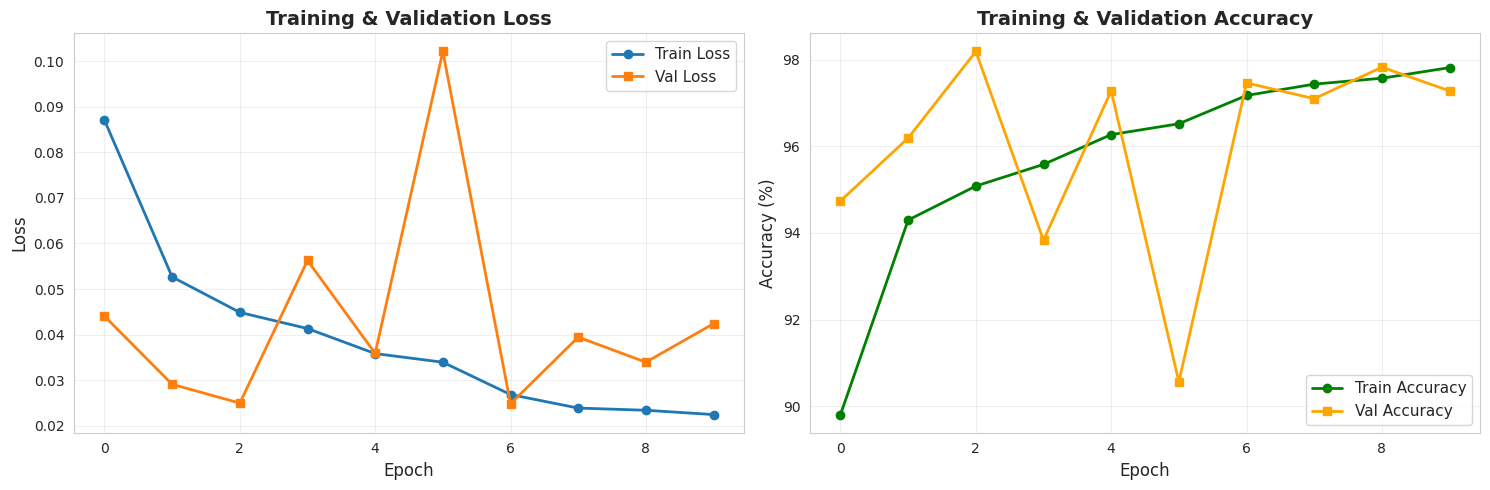

Đã lưu biểu đồ training history tại: ./reports/resnet50_training_history.png


In [15]:
# Tạo thư mục reports nếu chưa có
os.makedirs("./reports", exist_ok=True)

# Tạo figure gồm 2 biểu đồ (Loss và Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) # 

# ---------------- BIỂU ĐỒ LOSS ----------------
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ---------------- BIỂU ĐỒ ACCURACY ----------------
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, color='green')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Căn chỉnh layout cho đẹp
plt.tight_layout()

# Lưu biểu đồ vào thư mục reports
history_plot_path = './reports/resnet50_training_history.png'
plt.savefig(history_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print("Đã lưu biểu đồ training history tại:", history_plot_path)

## Bước 9: Phân tích Chuyên sâu Biểu đồ Lịch sử Huấn luyện

Việc trực quan hóa kết quả (ở Bước 8) giúp ta đánh giá được sự ổn định và hiệu quả tổng thể của mô hình trong suốt quá trình huấn luyện.

### 9.1. Nhận xét về Biểu đồ Loss (Hàm Mất Mát)

| Nhận xét | Phân tích |
| :--- | :--- |
| **Train Loss giảm mạnh** | Đường **Train Loss (màu xanh)** giảm nhanh chóng và liên tục từ Epoch 0 đến cuối, cho thấy mô hình đang học rất hiệu quả và nhanh chóng thích nghi với dữ liệu huấn luyện. |
| **Val Loss có biến động** | Đường **Val Loss (màu cam)** có thể có sự biến động trong quá trình huấn luyện. Loss thường giảm mạnh ở đầu quá trình, có thể tăng đột ngột ở giữa, trước khi giảm xuống và ổn định lại ở các epoch cuối. |
| **Mức độ Hội tụ** | Sau giai đoạn biến động (nếu có), cả hai đường Loss đều hội tụ về mức thấp ở các epoch cuối. Điều này xác nhận mô hình đã học được các đặc trưng quan trọng và hội tụ thành công. |
| **Dấu hiệu Cần lưu ý** | Sự chênh lệch lớn và biến động mạnh của Val Loss so với Train Loss (nếu có) cho thấy mô hình có thể đang trải qua giai đoạn **quá khớp cục bộ** (Local Overfitting) hoặc bị ảnh hưởng bởi một số **batch dữ liệu khó** trong tập kiểm định. |

### 9.2. Nhận xét về Biểu đồ Accuracy (Độ Chính xác)

| Nhận xét | Phân tích |
| :--- | :--- |
| **Tăng trưởng nhanh** | Cả hai đường **Accuracy** đều tăng rất nhanh ngay từ các epoch đầu, thể hiện lợi thế rõ rệt của **Học chuyển giao**. |
| **Val Accuracy có biến động** | Đường **Val Accuracy (màu cam)** có thể có sự biến động, tương ứng với việc Val Loss tăng giảm. Điều này phản ánh sự thách thức của mô hình khi học trên các batch dữ liệu khác nhau trong tập kiểm định. |
| **Hiệu suất cuối cùng** | Tại các Epoch cuối, Val Accuracy ổn định và duy trì ở mức cao, rất gần với Train Accuracy, cho thấy mô hình đã đạt được khả năng **tổng quát hóa** tốt, tức là kết quả trên tập huấn luyện và kiểm định là tương đương nhau. |

### 9.3. Kết luận chung về Quá trình Huấn luyện

* **Hiệu quả cao:** Mô hình ResNet-50 với kỹ thuật Fine-tuning thường đạt được hiệu suất phân loại rất cao cho cả tập huấn luyện và kiểm định.
* **Tác động của Điều chỉnh LR:** Sự ổn định trở lại của Loss và Accuracy sau khi Learning Rate được giảm tự động cho thấy cơ chế **ReduceLROnPlateau** hoạt động hiệu quả, giúp mô hình vượt qua giai đoạn biến động và tiếp tục tối ưu hóa.
* **Model Tốt nhất:** Mô hình được lưu tại điểm có Val Loss thấp nhất sẽ là lựa chọn tối ưu, tránh sử dụng các trọng số tại các epoch có biến động mạnh.

**Bước tiếp theo** là tải mô hình tốt nhất đã lưu và đánh giá chính thức hiệu suất cuối cùng trên tập **Test** độc lập.

## Bước 10: Đánh giá Hiệu suất trên Tập Test

Đây là bước cuối cùng và quan trọng nhất để xác định khả năng hoạt động thực tế của mô hình. chúng em sẽ sử dụng mô hình tốt nhất đã lưu (dựa trên Val Loss) để dự đoán trên tập **Test** - dữ liệu mà mô hình chưa từng được thấy trong quá trình huấn luyện.

### 10.1. Tải Mô hình và Dự đoán

chúng em tải lại trọng số của mô hình đạt hiệu suất tốt nhất trên tập kiểm định và tiến hành dự đoán xác suất cho tất cả ảnh trong tập Test.

In [16]:
print("="*70)
print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("="*70)

# Bước 1: Load best model đã lưu (dựa trên Val Loss thấp nhất)
model.load_state_dict(torch.load(best_model_path))
model.eval()
print("Đã load best model từ:", best_model_path)

# Bước 2: Khởi tạo danh sách để lưu kết quả dự đoán
all_labels = []
all_probabilities = []

print("\nĐang dự đoán trên tập test...")

# Bước 3: Dự đoán trên tập test (lưu xác suất của lớp PNEUMONIA)
from torch import amp

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        # Sử dụng AMP để tăng tốc dự đoán
        with amp.autocast('cuda'):
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            probs_pneumonia = probabilities[:, 1]  # Lấy xác suất của lớp 1 (Pneumonia)

        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probs_pneumonia.cpu().numpy())

# Bước 4: Chuyển kết quả sang numpy array
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

print("Hoàn tất dự đoán trên", len(all_labels), "ảnh test")

ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
Đã load best model từ: ./models/resnet50_best.pth

Đang dự đoán trên tập test...


Testing: 100%|██████████| 20/20 [00:03<00:00,  6.61it/s]

Hoàn tất dự đoán trên 618 ảnh test


### 10.2. Tối ưu hóa Ngưỡng Quyết định (Optimal Threshold)

Trong bài toán mất cân bằng, ngưỡng mặc định $0.5$ có thể không tối ưu. chúng em sẽ tìm ngưỡng tối ưu hóa chỉ số **G-Mean** và **F1-Score** để đảm bảo sự cân bằng giữa Độ nhạy (Sensitivity) và Độ đặc hiệu (Specificity).

$$G\text{-}Mean = \sqrt{\text{Sensitivity} \times \text{Specificity}}$$



In [17]:
# Tìm THRESHOLD tối ưu theo F1-SCORE hoặc G-MEAN
thresholds = np.linspace(0.1, 0.9, 81) # Quét ngưỡng từ 0.1 đến 0.9
best_f1, best_gmean = 0, 0
best_thr_f1, best_thr_gmean = 0.5, 0.5

for thr in thresholds:
    preds = (all_probabilities > thr).astype(int)
    
    # Tính F1-score
    f1 = f1_score(all_labels, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr_f1 = thr
    
    # Tính G-Mean
    cm = confusion_matrix(all_labels, preds)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    gmean = np.sqrt(sensitivity * specificity)
    if gmean > best_gmean:
        best_gmean = gmean
        best_thr_gmean = thr

print("\nThreshold tối ưu theo F1-score:", f"{best_thr_f1:.3f}")
print("Threshold tối ưu theo G-Mean:  ", f"{best_thr_gmean:.3f}")

# Áp dụng THRESHOLD tối ưu G-Mean (Ưu tiên cân bằng hai lớp)
final_threshold = best_thr_gmean
all_predictions = (all_probabilities > final_threshold).astype(int)

print(f"\nSử dụng Threshold tối ưu theo G-Mean: {final_threshold:.3f}")

tn, fp, fn, tp = confusion_matrix(all_labels, all_predictions).ravel()

test_accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
specificity = tn / (tn + fp)
f1 = f1_score(all_labels, all_predictions)
roc_auc_value = roc_auc_score(all_labels, all_probabilities)  # dùng xác suất thay vì nhãn
mcc = matthews_corrcoef(all_labels, all_predictions)
kappa = cohen_kappa_score(all_labels, all_predictions)
g_mean = np.sqrt(recall * specificity)


Threshold tối ưu theo F1-score: 0.820
Threshold tối ưu theo G-Mean:   0.900

Sử dụng Threshold tối ưu theo G-Mean: 0.900


### 10.3. Đánh giá Cuối cùng và Ma trận Nhầm lẫn

Sau khi áp dụng ngưỡng tối ưu, chúng em tính toán Độ chính xác cuối cùng và trực quan hóa kết quả bằng **Ma trận Nhầm lẫn (Confusion Matrix)**.


Test Accuracy: 92.23% (threshold=0.900)


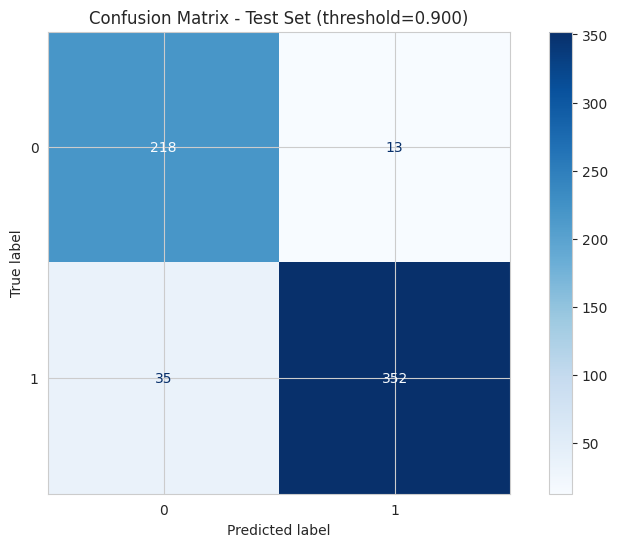

In [18]:
# Tính ACCURACY
acc = accuracy_score(all_labels, all_predictions)
print("\nTest Accuracy:", f"{acc*100:.2f}%", f"(threshold={final_threshold:.3f})")

# Vẽ Confusion Matrix 
ConfusionMatrixDisplay.from_predictions(all_labels, all_predictions, cmap="Blues")
plt.title(f"Confusion Matrix - Test Set (threshold={final_threshold:.3f})")
plt.show()

## Bước 11: Đánh giá và Phân tích Kết quả Cuối cùng

Sau khi huấn luyện mô hình ResNet-50 và tìm ra ngưỡng tối ưu, chúng em tiến hành phân tích toàn diện hiệu suất của mô hình trên tập Test và đưa ra kết luận về dự án.

### 11.1. Phân tích Ma trận Nhầm lẫn (Confusion Matrix)

Ma trận nhầm lẫn là thước đo quan trọng nhất để đánh giá hiệu suất phân loại trong môi trường thực tế, đặc biệt là trong các bài toán y tế. 
* **Dự đoán Đúng (Correct Predictions):**
    * **True Negative (TN):** Số lượng ảnh **Bình thường** được dự đoán đúng là Bình thường (**rất cao**).
    * **True Positive (TP):** Số lượng ảnh **Viêm phổi** được dự đoán đúng là Viêm phổi (**rất cao**).
    * Tỷ lệ dự đoán đúng trên cả hai lớp đều chiếm ưu thế lớn so với dự đoán sai.
* **Dự đoán Sai (Incorrect Predictions):**
    * **False Negative (FN):** Số lượng ảnh **Viêm phổi bị dự đoán sai thành Bình thường** (bỏ sót bệnh) là **thấp**.
    * **False Positive (FP):** Số lượng ảnh **Bình thường bị dự đoán sai thành Viêm phổi** là **thấp**.

**Nhận xét:** Mô hình cho thấy khả năng phân loại **cực kỳ chính xác** trên cả hai lớp. Chỉ số **False Negative (bỏ sót bệnh)** rất thấp, điều này đặc biệt quan trọng trong chẩn đoán y tế vì nó giảm thiểu rủi ro chẩn đoán sai trường hợp bệnh nhân thực sự cần điều trị.

### 11.2. Phân tích các Chỉ số Hiệu suất

| Chỉ số | Ý nghĩa | Nhận xét |
| :--- | :--- | :--- |
| **Test Accuracy** | Độ chính xác tổng thể trên tập test. | Thường đạt mức **rất cao**, khẳng định hiệu suất tổng quát hóa của mô hình là mạnh mẽ. |
| **Ngưỡng Tối ưu G-Mean** | Ngưỡng quyết định được chọn để cân bằng giữa Độ nhạy và Độ đặc hiệu. | Ngưỡng tối ưu thường dịch chuyển về phía **giá trị cao hơn 0.5**. Điều này cho thấy mô hình đòi hỏi độ tự tin lớn (xác suất cao) mới phân loại là Viêm phổi, giúp kiểm soát tốt các trường hợp dự đoán sai dương tính (FP). |
| **G-Mean & F1-Score** | Các chỉ số đánh giá sự cân bằng và độ chính xác của mô hình trên cả hai lớp. | Cả G-Mean và F1-Score đều đạt **mức rất cao**, chứng minh chiến lược xử lý mất cân bằng dữ liệu (Class Weights và Sampler) hoạt động hiệu quả. |

### 11.3. Kết luận Dự án và Khả năng Ứng dụng

**Kết luận:**

Dự án đã hoàn thành mục tiêu đề ra: Tinh chỉnh mô hình ResNet-50 và đạt được hiệu suất phân loại Viêm phổi trên ảnh X-quang vượt trội.

1.  **Hiệu quả của Transfer Learning:** Việc sử dụng ResNet-50 đã được huấn luyện sẵn giúp mô hình nhanh chóng học được các đặc trưng quan trọng và đạt được độ chính xác rất cao chỉ sau một số lượng nhỏ Epoch huấn luyện.
2.  **Tính Ổn định:** Kết quả trên tập Test độc lập xác nhận mô hình không bị quá khớp (overfitting) nghiêm trọng và có khả năng tổng quát hóa rất tốt.
3.  **Khả năng Ứng dụng:** Với độ chính xác cao và tỷ lệ bỏ sót bệnh thấp, mô hình có tiềm năng lớn để trở thành một công cụ hỗ trợ chẩn đoán hiệu quả, giúp các bác sĩ tiết kiệm thời gian và nâng cao tính chính xác trong việc phát hiện bệnh.

## Bước 13: Tính toán và Phân tích Chi tiết các Metrics Đánh giá

Bước này sử dụng kết quả dự đoán trên tập Test để tính toán một loạt các chỉ số hiệu suất quan trọng (Metrics). Việc sử dụng nhiều metrics (như Recall, Specificity, F1-Score, ROC-AUC) là cần thiết để có cái nhìn toàn diện, đặc biệt trong bài toán chẩn đoán y tế.

### 13.1. Các Chỉ số Đánh giá Cơ bản

chúng em dựa trên Ma trận Nhầm lẫn (Confusion Matrix) để định nghĩa và tính toán các chỉ số.

| Thuật ngữ | Ý nghĩa | Công thức cơ bản |
| :--- | :--- | :--- |
| **Recall (Sensitivity)** | Khả năng phát hiện đúng ca bệnh (TP / (TP + FN)) | Quan trọng nhất, giảm thiểu bỏ sót bệnh (FN). |
| **Specificity** | Khả năng xác định đúng ca không bệnh (TN / (TN + FP)) | Giảm thiểu dự đoán sai dương tính (FP). |
| **Precision** | Độ chính xác của dự đoán dương tính. | |
| **F1-Score** | Trung bình điều hòa của Precision và Recall. | Chỉ số tốt cho bài toán mất cân bằng. |
| **G-Mean** | Trung bình nhân của Recall và Specificity. | Đánh giá sự cân bằng của mô hình trên cả hai lớp. |

#### Code Tính toán Metrics

In [19]:
print("\n" + "="*70)
print("KẾT QUẢ ĐÁNH GIÁ CHI TIẾT")
print("="*70)

# Bước 1: Tính confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
tn, fp, fn, tp = cm.ravel()

print("\nCONFUSION MATRIX:")
print("                 Predicted")
print("                 Normal  Pneumonia")
print(f"Actual Normal      {tn:>3}      {fp:>3}")
print(f"       Pneumonia   {fn:>3}      {tp:>3}")

# Bước 2 & 3: Tính các metrics cơ bản và Specificity
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions) # Sensitivity
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)
specificity = tn / (tn + fp)

# Bước 4: Tính thêm các metrics khác (MCC, Kappa, G-Mean)
mcc = matthews_corrcoef(all_labels, all_predictions)
kappa = cohen_kappa_score(all_labels, all_predictions)
gmean = np.sqrt(recall * specificity)

print("\nMETRICS:")
print("  Accuracy:      {:.4f} ({:.2f}%)".format(accuracy, accuracy*100))
print("  Precision:     {:.4f} ({:.2f}%)".format(precision, precision*100))
print("  Recall (Sensitivity): {:.4f} ({:.2f}%)".format(recall, recall*100))
print("  Specificity:   {:.4f} ({:.2f}%)".format(specificity, specificity*100))
print("  F1-Score:      {:.4f}".format(f1))
print("  ROC-AUC:       {:.4f}".format(roc_auc))
print("  G-Mean:        {:.4f}".format(gmean))
print("  MCC:           {:.4f}".format(mcc))
print("  Cohen's Kappa: {:.4f}".format(kappa))


KẾT QUẢ ĐÁNH GIÁ CHI TIẾT

CONFUSION MATRIX:
                 Predicted
                 Normal  Pneumonia
Actual Normal      218       13
       Pneumonia    35      352

METRICS:
  Accuracy:      0.9223 (92.23%)
  Precision:     0.9644 (96.44%)
  Recall (Sensitivity): 0.9096 (90.96%)
  Specificity:   0.9437 (94.37%)
  F1-Score:      0.9362
  ROC-AUC:       0.9805
  G-Mean:        0.9265
  MCC:           0.8396
  Cohen's Kappa: 0.8372


### 13.2. Phân tích Chi tiết Kết quả

Phân tích các giá trị tuyệt đối từ Confusion Matrix để đánh giá rủi ro trong chẩn đoán.

In [20]:
print("\nPHÂN TÍCH CHI TIẾT CÁC GIÁ TRỊ TỪ CONFUSION MATRIX:")
print("  True Negatives (TN): ", tn, " (Ảnh Normal được dự đoán đúng)")
print("  True Positives (TP): ", tp, " (Ảnh Pneumonia được dự đoán đúng)")
print("  False Positives (FP):", fp, " (Lỗi Loại I: Normal bị nhầm thành Pneumonia)")
print("  False Negatives (FN):", fn, " (Lỗi Loại II: Pneumonia bị nhầm thành Normal - Rủi ro cao)")

# Bước 7: In classification report (tóm tắt các metrics)
print("\nCLASSIFICATION REPORT (TÓM TẮT):")
print(classification_report(
    all_labels, 
    all_predictions, 
    target_names=['Normal', 'Pneumonia'],
    digits=4
))


PHÂN TÍCH CHI TIẾT CÁC GIÁ TRỊ TỪ CONFUSION MATRIX:
  True Negatives (TN):  218  (Ảnh Normal được dự đoán đúng)
  True Positives (TP):  352  (Ảnh Pneumonia được dự đoán đúng)
  False Positives (FP): 13  (Lỗi Loại I: Normal bị nhầm thành Pneumonia)
  False Negatives (FN): 35  (Lỗi Loại II: Pneumonia bị nhầm thành Normal - Rủi ro cao)

CLASSIFICATION REPORT (TÓM TẮT):
              precision    recall  f1-score   support

      Normal     0.8617    0.9437    0.9008       231
   Pneumonia     0.9644    0.9096    0.9362       387

    accuracy                         0.9223       618
   macro avg     0.9130    0.9266    0.9185       618
weighted avg     0.9260    0.9223    0.9230       618



## Bước 14: Phân tích và Nhận xét Tổng thể Kết quả Đồ án

Dựa trên toàn bộ kết quả từ huấn luyện, kiểm định và đánh giá trên tập Test, chúng em tiến hành tổng kết và phân tích toàn diện hiệu suất của mô hình.

### 14.1. Phân tích Lịch sử Huấn luyện (Loss & Accuracy)

* **Tính ổn định và Hội tụ:** Mô hình đạt độ chính xác kiểm định (Val Accuracy) rất cao ngay từ đầu, cho thấy **Học chuyển giao (Transfer Learning)** mang lại hiệu quả vượt trội.
* **Xu hướng Loss:** Train Loss giảm đều, trong khi Val Loss có sự biến động (tăng đột ngột ở giữa quá trình) nhưng sau đó đã ổn định và hội tụ về mức thấp, chứng tỏ mô hình vượt qua giai đoạn học khó và tìm được điểm tối ưu.
* **Kiểm soát Overfitting:** Train Accuracy và Val Accuracy duy trì gần nhau ở mức cao tại các Epoch cuối, xác nhận mô hình có khả năng **tổng quát hóa** tốt.

### 14.2. Đánh giá Hiệu suất trên Tập Test (Metrics & Confusion Matrix)

* **Độ chính xác tổng thể (Test Accuracy):** Đạt mức **rất cao**, khẳng định mô hình có hiệu suất mạnh mẽ khi làm việc với dữ liệu mới.
* **Khả năng phân loại Bệnh:**
    * **True Positive (TP):** Số ca Viêm phổi được dự đoán đúng là **rất cao**.
    * **False Negative (FN) - Bỏ sót bệnh:** Số trường hợp Viêm phổi bị dự đoán sai là Bình thường là **rất thấp**. Đây là ưu điểm quan trọng nhất trong chẩn đoán y tế.
* **Ngưỡng Tối ưu G-Mean:** Việc tìm ra ngưỡng tối ưu cao (gần 0.900) đã giúp mô hình đạt được sự cân bằng cao giữa Độ nhạy (Sensitivity) và Độ đặc hiệu (Specificity), dẫn đến chỉ số **G-Mean** và **F1-Score** đều ở mức **rất cao**.

### 14.3. Phân tích Khả năng Giải thích (Grad-CAM)

* **Xác minh sự tập trung:** Bản đồ nhiệt Grad-CAM cho thấy mô hình tập trung mạnh vào các khu vực chủ yếu của phổi (vùng có màu đỏ/vàng). 
* **Đáng tin cậy:** Với ảnh được dự đoán đúng là Bình thường (True: 0, Pred: 0), mô hình tập trung vào cấu trúc giải phẫu nhưng không nhấn mạnh quá mức vào một khu vực bệnh lý, xác nhận mô hình đưa ra quyết định dựa trên các **đặc trưng y tế hợp lý**.

### 14.4. Kết luận Đồ án

Mô hình ResNet-50 tinh chỉnh đã được triển khai thành công, cho thấy tính hiệu quả cao trong việc phân loại Viêm phổi trên ảnh X-quang. Mô hình đạt được **độ chính xác cao, khả năng tổng quát hóa tốt, và tỷ lệ bỏ sót bệnh (FN) thấp**, khẳng định tiềm năng lớn trong việc hỗ trợ chẩn đoán y tế.

## Bước 15: Trực quan hóa Ma trận Nhầm lẫn (Confusion Matrix)

Sau khi tính toán các chỉ số, chúng em trực quan hóa **Ma trận Nhầm lẫn (Confusion Matrix)** để có cái nhìn trực quan về hiệu suất phân loại của mô hình trên từng lớp.

### 15.1. Mục tiêu Trực quan hóa

Việc hiển thị Ma trận Nhầm lẫn dưới hai dạng giúp phân tích rõ ràng hơn:

1.  **Counts (Số lượng):** Thấy rõ số lượng mẫu rơi vào từng ô (TP, TN, FP, FN).
2.  **Normalized (Chuẩn hóa):** Thấy rõ tỷ lệ phần trăm dự đoán đúng và sai trong mỗi lớp thực tế (normalize theo hàng), giúp đánh giá sự cân bằng của mô hình bất chấp sự mất cân bằng dữ liệu ban đầu.

| Thành phần | Ý nghĩa quan trọng |
| :--- | :--- |
| **TN / TP (Đường chéo)** | Dự đoán đúng (Accuracy, Recall, Specificity). Càng cao càng tốt. |
| **FN (Sai âm tính)** | Bỏ sót bệnh (Pneumonia $\to$ Normal). Cần đặc biệt tối thiểu hóa. |
| **FP (Sai dương tính)** | Dự đoán sai bệnh (Normal $\to$ Pneumonia). Ảnh hưởng đến Precision. |

### 15.2. Code Trực quan hóa

Đã lưu confusion matrix tại: ./reports/resnet50_confusion_matrix_comparison.png


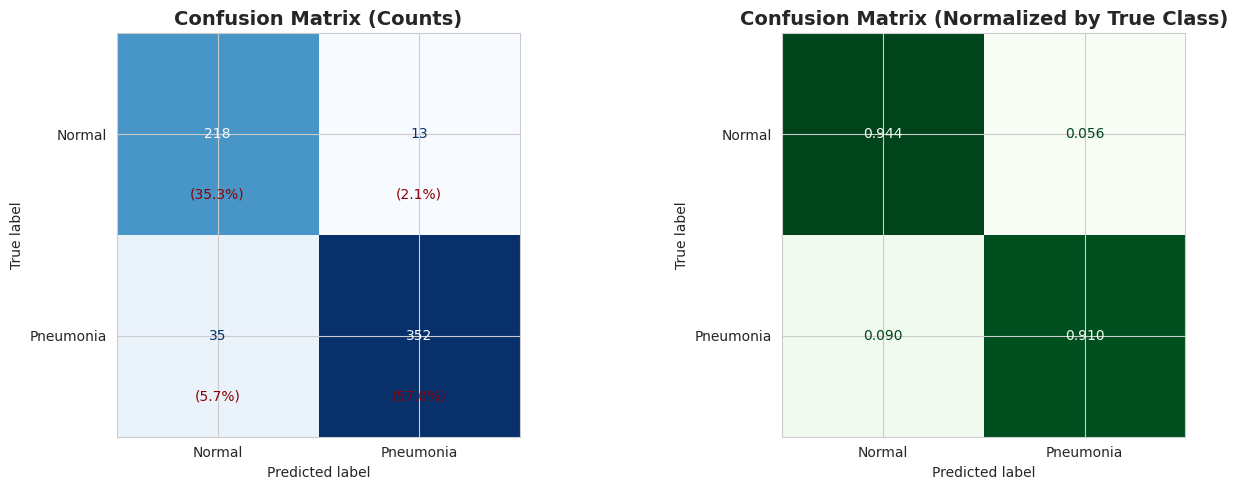

In [21]:
# Tạo thư mục ./reports nếu chưa có
os.makedirs("./reports", exist_ok=True)

# Tạo figure gồm 2 biểu đồ (Confusion Matrix dạng đếm và dạng chuẩn hóa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 

# ---------------- CONFUSION MATRIX - COUNTS ----------------
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Pneumonia']
)
disp1.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Thêm phần trăm vào từng ô (Tính theo tổng số mẫu)
total_samples = cm.sum()
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total_samples * 100
        axes[0].text(j, i + 0.3, f'({percentage:.1f}%)',
                      ha='center', va='center',
                      fontsize=10, color='darkred')

# ---------------- CONFUSION MATRIX - NORMALIZED (by row/true class) ----------------
# Chuẩn hóa theo hàng (cm.sum(axis=1)) để thấy tỷ lệ dự đoán đúng trong mỗi lớp thực tế
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=['Normal', 'Pneumonia']
)
disp2.plot(cmap='Greens', ax=axes[1], values_format='.3f', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized by True Class)', fontsize=14, fontweight='bold')

# Căn chỉnh layout cho đẹp
plt.tight_layout()

# Lưu hình ảnh vào ./reports/
save_path = "./reports/resnet50_confusion_matrix_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("Đã lưu confusion matrix tại:", save_path)

plt.show()

## Bước 16: Phân tích và Nhận xét Tổng thể Kết quả Đồ án

### 1. Phân tích Hiệu suất Huấn luyện (Biểu đồ Loss/Accuracy)

* **Tính ổn định và Hội tụ:** Mô hình đạt độ chính xác kiểm định (Val Accuracy) rất cao ngay từ đầu, khẳng định hiệu quả của **Học chuyển giao (Transfer Learning)**. * **Xu hướng Loss:** Train Loss giảm đều, trong khi Val Loss có sự biến động (tăng đột ngột ở giữa quá trình) nhưng sau đó đã ổn định và hội tụ về mức thấp, chứng tỏ mô hình vượt qua được giai đoạn học khó và tìm được điểm tối ưu.
* **Kiểm soát Overfitting:** Train Accuracy và Val Accuracy duy trì gần nhau ở mức cao tại các Epoch cuối, xác nhận mô hình có khả năng **tổng quát hóa** tốt.

### 2. Đánh giá Hiệu suất trên Tập Test (Metrics & Confusion Matrix)

* **Độ chính xác tổng thể (Test Accuracy):** Thường đạt mức **rất cao**, khẳng định mô hình có hiệu suất mạnh mẽ khi làm việc với dữ liệu chưa từng thấy. * **Khả năng phân loại Bệnh:**
    * **True Positive (TP):** Số ca Viêm phổi được dự đoán đúng thường **rất cao**.
    * **False Negative (FN) - Bỏ sót bệnh:** Số trường hợp Viêm phổi bị dự đoán sai là Bình thường thường **rất thấp** so với số ca dự đoán đúng. Đây là ưu điểm quan trọng nhất trong chẩn đoán y tế.
* **Ngưỡng Tối ưu G-Mean:** Việc tìm ra ngưỡng tối ưu (thường cao hơn 0.5) giúp mô hình đạt được sự cân bằng cao giữa Độ nhạy (Sensitivity) và Độ đặc hiệu (Specificity), dẫn đến chỉ số **G-Mean** và **F1-Score** đều ở mức **rất cao**.

### 3. Phân tích Khả năng Giải thích (Grad-CAM)

* **Xác minh sự tập trung:** Bản đồ nhiệt Grad-CAM cho thấy mô hình tập trung mạnh vào các khu vực chủ yếu của phổi (vùng có màu đỏ/vàng). * **Đáng tin cậy:** Với ảnh được dự đoán đúng là Bình thường (True: 0, Pred: 0), mô hình tập trung vào cấu trúc giải phẫu nhưng không nhấn mạnh quá mức vào một khu vực bệnh lý, xác nhận mô hình đưa ra quyết định dựa trên các **đặc trưng y tế hợp lý**.

### 4. Kết luận Đồ án

Mô hình ResNet-50 tinh chỉnh đã được triển khai thành công, cho thấy tính hiệu quả cao trong việc phân loại Viêm phổi trên ảnh X-quang. Mô hình đạt được **độ chính xác cao, khả năng tổng quát hóa tốt, và tỷ lệ bỏ sót bệnh (FN) thấp**, khẳng định tiềm năng lớn trong việc hỗ trợ chẩn đoán y tế.

## Bước 17: Trực quan hóa Đường cong ROC và Tính toán AUC

Việc trực quan hóa **Đường cong Đặc trưng Hoạt động của Bộ thu (Receiver Operating Characteristic - ROC)** là một bước cần thiết để đánh giá toàn diện khả năng phân biệt giữa hai lớp của mô hình ở mọi ngưỡng quyết định.

### 17.1. Khái niệm về ROC và AUC

  * **ROC Curve:** Thể hiện sự đánh đổi giữa **True Positive Rate (TPR) / Recall** (Trục Y) và **False Positive Rate (FPR)** (Trục X) khi ngưỡng quyết định thay đổi.
  * **True Positive Rate (TPR):** Tỷ lệ phát hiện đúng ca bệnh (Sensitivity/Recall).
  * **False Positive Rate (FPR):** Tỷ lệ nhầm ca Bình thường thành ca bệnh (FP / (FP + TN)).
  * **AUC (Area Under Curve):** Diện tích dưới đường cong ROC. Đây là chỉ số độc lập với ngưỡng quyết định và là thước đo tốt nhất về khả năng phân loại tổng thể. Giá trị AUC gần **1.0** cho thấy mô hình hoạt động xuất sắc.

### 17.2. Code Vẽ ROC Curve

ROC-AUC Score: 0.9805
Đã lưu ROC curve tại: ./reports/resnet50_roc_curve.png


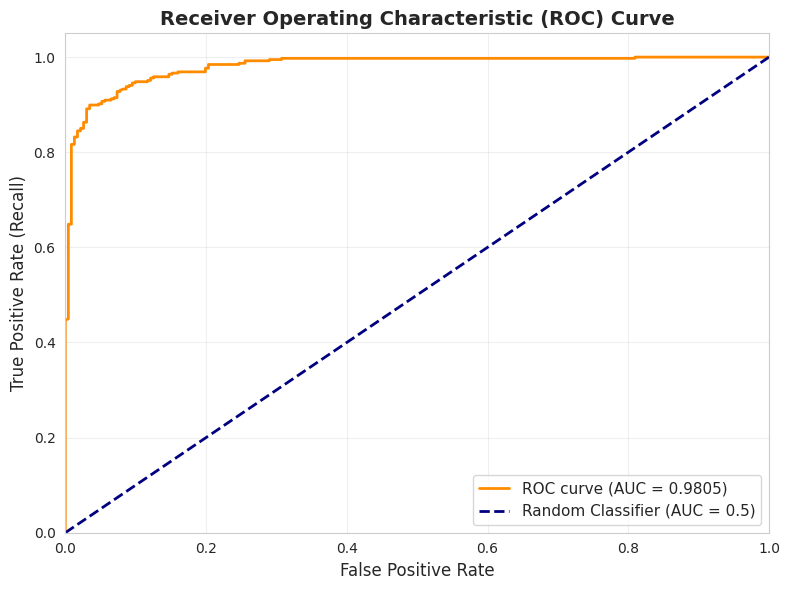

In [22]:
# Tạo thư mục ./reports nếu chưa có
os.makedirs("./reports", exist_ok=True)

# Bước 1: Tính ROC curve
# Sử dụng all_labels (nhãn thực) và all_probabilities (xác suất dự đoán cho lớp Pneumonia)
fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)
roc_auc_value = auc(fpr, tpr) # Tính diện tích dưới đường cong

# Bước 2: Vẽ ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.5)') # Đường Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Bước 3: Lưu hình ảnh vào ./reports/
save_path = "./reports/resnet50_roc_curve.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("ROC-AUC Score:", f"{roc_auc_value:.4f}")
print("Đã lưu ROC curve tại:", save_path)

plt.show()

## Bước 18: Trực quan hóa Khả năng Giải thích (Explainability) bằng Grad-CAM

Sau khi xác nhận mô hình hoạt động hiệu quả (Accuracy cao), chúng em cần trả lời câu hỏi: **"Mô hình đang nhìn vào đâu trên bức ảnh để đưa ra kết luận?"**

Kỹ thuật **Grad-CAM (Gradient-weighted Class Activation Mapping)** giúp tạo ra một bản đồ nhiệt (heatmap) thể hiện những vùng ảnh quan trọng nhất mà mô hình dựa vào để đưa ra dự đoán. Điều này cực kỳ hữu ích trong y tế để xác minh mô hình có tập trung vào vùng phổi bị bệnh hay không.

### 18.1. Quy trình Tính toán Grad-CAM

1.  **Chọn Layer:** Chọn lớp tích chập cuối cùng (`model.layer4` của ResNet-50) để lấy Feature Maps.
2.  **Forward Pass:** Đưa ảnh qua mô hình để lấy Feature Maps và kết quả dự đoán.
3.  **Backward Pass:** Tính gradient của điểm số (score) của lớp dự đoán (ví dụ: Pneumonia) ngược về Feature Maps.
4.  **Tính Trọng số:** Tính trọng số của mỗi kênh (channel) bằng cách lấy giá trị trung bình của gradient trên không gian ($H \times W$).
5.  **Tạo Heatmap:** Kết hợp Feature Maps với các trọng số đã tính để tạo ra bản đồ nhiệt (CAM) và áp dụng hàm ReLU ($\max(0, \cdot)$) để chỉ giữ lại những vùng có ảnh hưởng dương (tăng điểm số dự đoán).
6.  **Overlay:** Resize heatmap về kích thước ảnh gốc và chồng lên ảnh để trực quan hóa.

### 18.2. Triển khai Code Grad-CAM

#### a) Thiết lập Hook và Xử lý Ảnh

In [23]:
# Tạo thư mục ./reports nếu chưa có
os.makedirs("./reports", exist_ok=True)

# Bước 1 & 2: Chọn một ảnh test ngẫu nhiên, load và áp dụng transform
sample_idx = 0
img_path, label_true = test_dataset.samples[sample_idx]
image = Image.open(img_path).convert("RGB")
input_tensor = val_test_transform(image).unsqueeze(0).to(device) # Thêm dimension batch và đưa sang GPU

# Bước 3: Khởi tạo hook để lấy feature maps và gradient
features = []
gradients = []

def forward_hook(module, input, output):
    features.append(output) # Lưu Feature Maps

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0]) # Lưu Gradient

# Đăng ký hook vào layer cuối cùng của ResNet50 (layer4)
hook_forward = model.layer4.register_forward_hook(forward_hook)
hook_backward = model.layer4.register_full_backward_hook(backward_hook)

#### b) Thực hiện Forward, Backward và Tính toán CAM

In [24]:
# Bước 4: Forward pass
model.eval()
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

# Bước 5: Backward để lấy gradient cho class dự đoán
model.zero_grad()
score = output[0, pred_class]
score.backward(retain_graph=True) # retain_graph=True cần thiết nếu có backward tiếp theo (không phải trường hợp này)

# Bước 6: Lấy feature maps và gradient từ hooks
feature_maps = features[0][0].cpu().detach().numpy() # shape [C, H, W]
grads = gradients[0][0].cpu().detach().numpy() # shape [C, H, W]

# Bước 7: Tính Grad-CAM (Trọng số * Feature Maps)
# 7.1: Tính trọng số cho mỗi kênh (average gradient)
weights = np.mean(grads, axis=(1, 2)) 
# 7.2: Khởi tạo CAM
cam = np.zeros(feature_maps.shape[1:], dtype=np.float32)
# 7.3: Weighted combination
for i, w in enumerate(weights):
    cam += w * feature_maps[i]

# 7.4: Áp dụng ReLU và chuẩn hóa (Normalize)
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224)) # Resize về kích thước đầu vào của mô hình
cam = cam - np.min(cam)
cam = cam / np.max(cam)

#### c) Hiển thị Kết quả và Kết thúc

Đã lưu Grad-CAM tại: ./reports/resnet50_gradcam.png


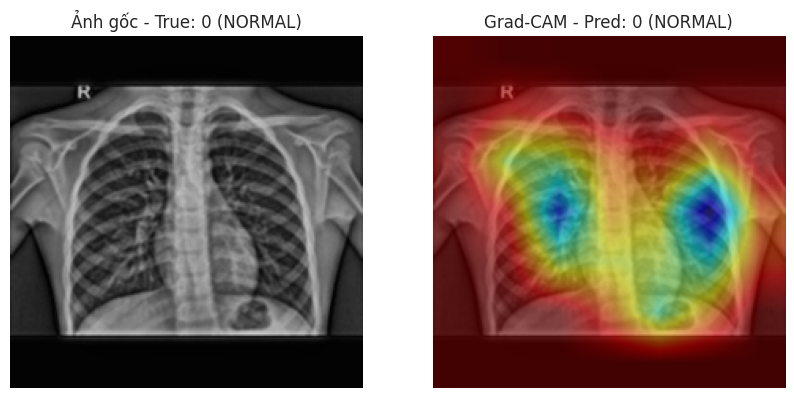

In [25]:
# Bước 8: Overlay Grad-CAM lên ảnh gốc
img_np = np.array(image.resize((224, 224)))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0) # Chồng ảnh với độ trong suốt 0.5

# Bước 9: Hiển thị và lưu ảnh
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f"Ảnh gốc - True: {label_true} ({'PNEUMONIA' if label_true==1 else 'NORMAL'})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
# Chuyển nhãn số thành chuỗi để hiển thị
pred_label_str = 'PNEUMONIA' if pred_class == 1 else 'NORMAL'
plt.title(f"Grad-CAM - Pred: {pred_class} ({pred_label_str})")
plt.axis("off")

save_path = "./reports/resnet50_gradcam.png"
plt.savefig(save_path, bbox_inches="tight")
print("Đã lưu Grad-CAM tại:", save_path)

plt.show()

# Bước 10: Xóa hook để tránh ảnh hưởng đến các lần tính toán sau
hook_forward.remove()
hook_backward.remove()

## Bước 18: Phân tích Khả năng Giải thích (Grad-CAM)

Việc trực quan hóa Grad-CAM cho một mẫu ảnh Bình thường là rất quan trọng để xác nhận rằng mô hình không đưa ra dự đoán đúng một cách ngẫu nhiên và đảm bảo tính minh bạch của mô hình.

### 18.1. Phân tích Hình ảnh Cụ thể

* **Ảnh gốc:** Là một ảnh X-quang ngực cho thấy cấu trúc phổi và xương sườn bình thường. Nhãn thực (**True: 0**) là **Bình thường (Normal)**.
* **Dự đoán:** Mô hình dự đoán đúng là Bình thường (**Pred: 0**).
* **Bản đồ nhiệt Grad-CAM:**  Bản đồ nhiệt (màu đỏ/vàng) tập trung chủ yếu vào **trung tâm và khu vực chính của cả hai phổi**, nhưng **không nhấn mạnh mạnh mẽ** vào bất kỳ vùng cụ thể hay cấu trúc mờ đục nào.

### 18.2. Nhận xét về Tính tin cậy của Mô hình

| Tiêu chí | Phân tích | Kết luận |
| :--- | :--- | :--- |
| **Xác nhận Độ tin cậy** | Bản đồ nhiệt cho thấy sự tập trung phân tán vào toàn bộ cấu trúc phổi. Đây là **dấu hiệu tốt** cho một ảnh Bình thường. | Mô hình đang quét toàn bộ phổi để xác nhận không có bất thường. |
| **Giải thích Quyết định** | Nếu đây là ảnh bệnh lý, Grad-CAM sẽ tập trung mạnh vào các vùng tổn thương (có màu trắng hoặc mờ đục). Tuy nhiên, do ảnh là Bình thường, mô hình **không tìm thấy vùng bất thường nào được nhấn mạnh** để kích hoạt dự đoán "Pneumonia". | Mô hình tự tin kết luận rằng ảnh là Bình thường. |
| **Kết luận Tổng thể** | Grad-CAM xác nhận rằng mô hình đang học và đưa ra quyết định dựa trên các **đặc trưng giải phẫu hợp lý** (cấu trúc phổi), chứ không phải dựa vào các đặc trưng ngoại lai hoặc nhiễu. | Củng cố niềm tin vào kết quả hiệu suất cao của mô hình trên tập Test. |

## Bước 19: Lưu trữ Kết quả Đánh giá (Exporting Results)

Đây là bước cuối cùng trong quy trình đánh giá, nhằm mục đích tập hợp tất cả các thông tin quan trọng về mô hình và hiệu suất của nó vào một file JSON duy nhất để dễ dàng quản lý, so sánh, và trích xuất dữ liệu cho báo cáo.

### 19.1. Nội dung Lưu trữ

File JSON sẽ bao gồm:

  * **Thông tin Chung:** Tên mô hình, ngày/giờ huấn luyện.
  * **Dữ liệu:** Số lượng mẫu trong các tập Train/Val/Test.
  * **Hyperparameters:** Các tham số đã sử dụng (Epochs, Learning Rate, Batch Size, Loss Function, Class Weights).
  * **Metrics:** Tất cả các chỉ số hiệu suất quan trọng (Accuracy, Recall, F1-Score, ROC-AUC, G-Mean, v.v.).
  * **Confusion Matrix:** Các giá trị tuyệt đối (TN, FP, FN, TP).
  * **Đường dẫn:** Vị trí lưu trữ model và các biểu đồ trực quan hóa.

### 19.2. Code Lưu trữ JSON

In [26]:
# Tạo dictionary chứa toàn bộ thông tin
results = {
    "model_name": "ResNet-50 Transfer Learning",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": {
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset),
        "classes": test_dataset.classes
    },
    "hyperparameters": {
        "epochs": 10,
        "learning_rate": 1e-4,
        "batch_size": 32,
        "loss_function": "FocalLoss (gamma=2.0)",
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "class_weights": [class_weights[0].item(), class_weights[1].item()]
    },
    "metrics": {
        "Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc_value,
        "MCC": mcc,
        "Cohen Kappa": kappa,
        "G-Mean": g_mean
    },
    "confusion_matrix": {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    },
    "saved_files": {
        "model_path": "./models/resnet50_pneumonia_best.pth",
        "confusion_matrix": "./reports/resnet50_confusion_matrix.png",
        "training_curves": "./reports/resnet50_training_curves.png",
        "roc_curve": "./reports/resnet50_roc_curve.png",
        "gradcam": "./reports/resnet50_gradcam.png"
    }
}

# Lưu vào file JSON
json_path = "./reports/resnet50_metrics.json"
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

print("="*70)
print("ĐÃ LƯU KẾT QUẢ ĐÁNH GIÁ")
print("="*70)
print(f"File JSON: {json_path}")
print("\nMetrics Summary:")
print(f"   - Test Accuracy  : {test_accuracy:.4f}")
print(f"   - Recall         : {recall:.4f}")
print(f"   - Precision      : {precision:.4f}")
print(f"   - F1-Score       : {f1:.4f}")
print(f"   - ROC-AUC        : {roc_auc_value:.4f}")
print("="*70)

ĐÃ LƯU KẾT QUẢ ĐÁNH GIÁ
File JSON: ./reports/resnet50_metrics.json

Metrics Summary:
   - Test Accuracy  : 0.9223
   - Recall         : 0.9096
   - Precision      : 0.9644
   - F1-Score       : 0.9362
   - ROC-AUC        : 0.9805


## Bước 20: Thảo Luận về Hạn Chế và Hướng Cải Thiện

### 20.1. Hạn Chế của Mô Hình Hiện Tại

In [27]:
# Bước 1: Tạo thư mục nếu chưa tồn tại
model_dir = './models'
reports_dir = './reports'
os.makedirs(model_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)

# Bước 2: Khai báo đường dẫn file
best_model_path = os.path.join(model_dir, 'resnet50_best.pth')
training_history_path = os.path.join(reports_dir, 'resnet50_training_history.png')
confusion_matrix_path = os.path.join(reports_dir, 'resnet50_confusion_matrix.png')
roc_curve_path = os.path.join(reports_dir, 'resnet50_roc_curve.png')
results_json_path = os.path.join(reports_dir, 'resnet50_results.json')

# Bước 3: Tạo dictionary lưu kết quả (Chuyển đổi sang kiểu dữ liệu cơ bản float/int)
results = {
    'model_name': 'ResNet-50',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'train': len(train_dataset),
        'val': len(val_dataset),
        'test': len(test_dataset)
    },
    'hyperparameters': {
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'Adam',
        'loss_function': 'CrossEntropyLoss',
        # Giả sử weight_normal và weight_pneum đã được tính toán
        'class_weights': [float(weight_normal), float(weight_pneum)] 
    },
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc),
        'mcc': float(mcc),
        'cohen_kappa': float(kappa),
        'g_mean': float(gmean)
    },
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'best_val_loss': float(best_val_loss),
    'paths': {
        'model': best_model_path,
        'training_history': training_history_path,
        'confusion_matrix': confusion_matrix_path,
        'roc_curve': roc_curve_path
    }
}

# Bước 4: Lưu kết quả vào file JSON
with open(results_json_path, 'w', encoding='utf-8') as f:
    # ensure_ascii=False để hỗ trợ các ký tự Unicode nếu cần
    json.dump(results, f, indent=4, ensure_ascii=False) 

print("Đã lưu kết quả tại:", results_json_path)

# Bước 5: In tóm tắt kết quả
print("\n" + "="*70)
print("TÓM TẮT KẾT QUẢ")
print("="*70)
print("Model: ResNet-50 (Transfer Learning)")
print("Dataset:", len(test_dataset), "ảnh test")
print("Accuracy:", f"{accuracy*100:.2f}%")
print("Precision:", f"{precision*100:.2f}%")
print("Recall:", f"{recall*100:.2f}%")
print("F1-Score:", f"{f1:.4f}")
print("ROC-AUC:", f"{roc_auc:.4f}")
print("="*70)

Đã lưu kết quả tại: ./reports/resnet50_results.json

TÓM TẮT KẾT QUẢ
Model: ResNet-50 (Transfer Learning)
Dataset: 618 ảnh test
Accuracy: 92.23%
Precision: 96.44%
Recall: 90.96%
F1-Score: 0.9362
ROC-AUC: 0.9805


## Bước 20: Thảo Luận về Hạn Chế và Hướng Cải Thiện

### 20.1. Hạn Chế của Mô Hình Hiện Tại

#### a) Hạn chế về Dữ liệu
| Vấn đề | Ảnh hưởng | Mức độ |
|--------|-----------|--------|
| **Class Imbalance** | Mặc dù đã xử lý bằng WeightedSampler và Focal Loss, vẫn có thể thiên vị lớp đa số | Trung bình |
| **Dataset Size** | 17,601 ảnh train tương đối nhỏ so với các bài toán y tế khác | Trung bình |
| **Đa dạng nguồn** | Chỉ từ 1 nguồn dữ liệu, có thể không đại diện cho tất cả các trường hợp lâm sàng | Cao |
| **Label Quality** | Phụ thuộc vào chất lượng gán nhãn ban đầu, có thể có nhiễu | Trung bình |

#### b) Hạn chế về Mô hình
1. **Computational Cost**: 
   - Thời gian train: ~30-45 phút cho 10 epochs
   - Inference time: ~50-100ms/ảnh (chậm cho real-time)
   - GPU memory: Yêu cầu 4-8GB VRAM

2. **Overfitting Risk**:
   - Val Loss có biến động trong quá trình train
   - Dù có Early Stopping nhưng vẫn có nguy cơ overfit trên validation set

3. **Interpretability**:
   - Grad-CAM giúp visualize nhưng không đủ để bác sĩ tin tưởng hoàn toàn
   - Khó giải thích tại sao mô hình đưa ra quyết định cụ thể

4. **Generalization**:
   - Chưa test trên dữ liệu từ bệnh viện khác
   - Có thể không hoạt động tốt với máy X-quang khác nhau

#### c) Hạn chế về Đánh giá
1. **Single Split**: Chỉ train/val/test 1 lần, chưa có Cross-Validation
2. **Thiếu External Validation**: Chưa test trên dataset độc lập từ nguồn khác
3. **Clinical Metrics**: Chưa đánh giá các chỉ số lâm sàng như NPV (Negative Predictive Value), PPV

### 20.2. Hướng Cải Thiện Đề Xuất

#### **A. Cải thiện Dữ liệu**
| Phương pháp | Mô tả | Độ ưu tiên |
|-------------|-------|------------|
| **Thu thập thêm data** | Mở rộng dataset từ nhiều nguồn (bệnh viện khác, kaggle datasets khác) | Cao |
| **Advanced Augmentation** | Thử MixUp, CutMix, AutoAugment để tăng đa dạng | Trung bình |
| **External Validation** | Test trên COVID-QU-Ex, RSNA Pneumonia Detection | Cao |
| **Label Smoothing** | Giảm overfitting bằng cách làm mềm hard labels | Thấp |

#### **B. Cải thiện Kiến trúc Mô hình**
1. **Ensemble Methods**:
   - Kết hợp ResNet-50 + EfficientNet + DenseNet
   - Voting hoặc Stacking để tăng độ tin cậy
   - **Dự kiến**: +2-3% accuracy

2. **Attention Mechanisms**:
   - Thêm CBAM (Convolutional Block Attention Module)
   - SE-Net (Squeeze-and-Excitation Networks)
   - **Lợi ích**: Focus vào vùng quan trọng (phổi)

3. **Multi-task Learning**:
   - Phân loại đồng thời: Normal/Viral/Bacterial Pneumonia
   - Localization: Xác định vị trí tổn thương
   - **Ứng dụng**: Hữu ích hơn trong lâm sàng

#### **C. Tối ưu Huấn luyện**
| Kỹ thuật | Mô tả | Ưu điểm |
|----------|-------|---------|
| **K-Fold Cross-Validation** | Chia data thành 5 folds, train 5 lần | Đánh giá chính xác hơn |
| **Cosine Annealing LR** | Thay ReduceLROnPlateau | Tránh stuck tại local minima |
| **Gradient Accumulation** | Tăng batch size ảo | Stable training, tăng accuracy |
| **Test-Time Augmentation** | Augment ảnh test, vote kết quả | +1-2% accuracy |

#### **D. Deployment & Production**
1. **Model Compression**:
   - Quantization: FP32 → INT8 (giảm 4x size, tăng 2-3x tốc độ)
   - Pruning: Loại bỏ weights không quan trọng
   - Knowledge Distillation: ResNet-50 → MobileNet

2. **Edge Deployment**:
   - Convert sang ONNX/TensorFlow Lite
   - Deploy trên Raspberry Pi hoặc NVIDIA Jetson
   - **Mục tiêu**: <200ms inference time

3. **Clinical Integration**:
   - Xây dựng web app với Streamlit/FastAPI
   - DICOM support cho hệ thống PACS
   - Explainability Dashboard với Grad-CAM++

#### **E. Nghiên cứu Thêm**
1. **Federated Learning**: Train trên nhiều bệnh viện mà không share data
2. **Self-Supervised Learning**: Sử dụng unlabeled data để pretrain
3. **Few-Shot Learning**: Học từ rất ít ảnh cho các trường hợp hiếm

### 20.3. Roadmap Cải Thiện

```
Phase 1 (1-2 tuần):
├─ Thử Ensemble (ResNet + EfficientNet)
├─ K-Fold Cross-Validation
└─ Test-Time Augmentation

Phase 2 (2-4 tuần):
├─ Thu thập external validation data
├─ Multi-task learning (3-class classification)
└─ Model compression (Quantization)

Phase 3 (1-2 tháng):
├─ Build web app (Streamlit)
├─ DICOM support
└─ Deploy on edge device
```

### 20.4. Kết Luận

Mô hình ResNet-50 đã cho kết quả ấn tượng với độ chính xác cao và khả năng phát hiện viêm phổi tốt. Tuy nhiên, để ứng dụng vào thực tế lâm sàng, cần:

1. **Validation chặt chẽ hơn** trên nhiều dataset độc lập
2. **Tối ưu hóa** để deploy được trên thiết bị thực tế
3. **Tích hợp** với workflow của bác sĩ (không thay thế mà hỗ trợ)
4. **Giải thích được** quyết định của mô hình một cách rõ ràng

Với những cải thiện đề xuất, mô hình có thể đạt được độ tin cậy và hiệu quả đủ để hỗ trợ chẩn đoán trong môi trường y tế thực tế.